# 1. Setup Awal
Langkah awal dari projek ini adalah mengunduh library yang dibutuhkan. Pada studi kasus kali ini, library Sastrawi digunakan untuk stemming kalimat berbahasa Indonesia dan meminta daftar stopword, sementara NLTK digunakan untuk tokenisasi.

In [1]:
!pip install sastrawi

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 5.4 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

# 2. Setup Dataset (Penyiapan Skorpus)
Demi mengatasi masalah reproducibility, dataset diambil dari kaggle, kemudian dilakukan penghapusan pada kolom yang tidak digunakan sehingga menyisakan dua kolom: judul dan isi artikel. Dataset kemudian diunduh dalam bentuk kompresi (.gz) dan diunggah ke github. Hasilnya, setiap jalan, reproducibility program akan sama dan pengguna tidak perlu mengunduh dataset lainnya.

In [2]:
import pandas as pd

data = "/kaggle/input/datasets/ariffaizin/indonesia-election-news-berita-pemilu-2024/news_data.csv"

df = pd.read_csv(data)
print(df.shape)
print(df.head())

(19813, 7)
                                               title      author  \
0  Hasto Ingin Debat Pilpres Pertarungan Gagasan ...   detikNews   
1  Terima Kunjungan Gibran di Ponpes Al-Tsaqafah,...   detikNews   
2  Contoh Format dan Isi Surat Pernyataan Anggota...   detikNews   
3  9 Ribu Personel Gabungan Dikerahkan Amankan Na...  detikSumut   
4  Amarah Ukraina Usai Rusia Bakal Gelar Pilpres ...   detikNews   

                publish_date  \
0  2023-12-10 23:31:00+07:00   
1  2023-12-10 23:09:00+07:00   
2  2023-12-10 22:38:00+07:00   
3  2023-12-10 22:23:00+07:00   
4  2023-12-10 22:12:00+07:00   

                                        article_text  \
0  Sekjen PDIP sekaligus Sekretaris Tim Pemenang ...   
1  Mantan Ketua Umum Pengurus Besar Nahdlatul Ula...   
2  Surat pernyataan KPPS Pemilu 2024 merupakan ba...   
3  Sekitar 9.000 personel dikerahkan untuk mengam...   
4  Ukraina marah usai Rusia menjadikan empat wila...   

                                                 u

Dataset yang terlalu banyak perlu dihapus sehingga tidak membebani komputasi. Pada kasus ini karena minimal 50 artikel, maka amannya akan dipotong menjadi 1000 artikel. Selain itu, beberapa kolom tidak perlu lebih baik di-drop

In [3]:
kolom_terpakai = ['article_text', 'title']

df = df[kolom_terpakai]

data_bersih = df.drop(df.index[1000:])
print(len(data_bersih))

1000


# 3. Setup Alat Preprocessing
Pada tahapan ini, alat alat untuk preprocessing seperti cleaning dari lib. re, tokenisasi dari NLTK, dan stemming + stopword dari sastrawi dibuat. Selain itu, dilakukan pengecekan terhadap missing value agar tidak eror pada bagian praprosesing

In [4]:
import re
import nltk
from nltk.tokenize import word_tokenize
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

stemmer = StemmerFactory().create_stemmer()
stopword_remover = StopWordRemoverFactory()
daftar_stopword = set(stopword_remover.get_stop_words())

In [5]:
print(data_bersih['article_text'].isna().sum())
print(data_bersih[data_bersih['article_text'].isna()])

0
Empty DataFrame
Columns: [article_text, title]
Index: []


In [6]:
data_bersih = data_bersih.dropna(subset=['article_text'])
print(data_bersih.isna().sum())

article_text    0
title           0
dtype: int64


# 4. Fungsi Preprocessing
Pada tahap ini dibuat beberapa fungsi preprocessing untuk menignkatkan reproducibility dan kemudahan dalam penggunaan. Fungsi dipecah menjadi beberapa bagian agar lebih mudah dalam mengukur tahapan tiap proses dan bertujuan untuk membangun kode yang lebih modular

In [7]:
# Case Folding
def case_folding(teks):
  teks = teks.lower()
  teks = re.sub(r'[^a-z\s]',' ',teks)
  teks = re.sub(r'\s+', ' ', teks).strip()
  return teks

#Tokenisasi
def tokenisasi(teks):
  return word_tokenize(teks)

#Pembuangan stopword
def hapus_stopword(tokens):
  return [kata for kata in tokens if kata not in daftar_stopword]

#Stemming dengan Sastrawi
def stemming(tokens):
  kalimat = ' '.join(tokens)
  hasil = stemmer.stem(kalimat)
  return hasil.split()

#Fungsi Utama
def praproses(teks_mentah):
  hasil_fold = case_folding(teks_mentah)
  hasil_token = tokenisasi(hasil_fold)
  token_bersih = hapus_stopword(hasil_token)
  token_stemming = stemming(token_bersih)
  return token_stemming

# 5. Pengukuran Dampak Tiap Tahap
Pengukuran dilakukan terhadap jumlah token dan tipe sebelum dan sesudah setiap tahap praprosesing.

In [8]:
def hitung_statistik(semua_token_dokumen):
  semua_token = [t for doc in semua_token_dokumen for t in doc]
  jumlah_token = len(semua_token)
  jumlah_tipe = len(set(semua_token))
  return jumlah_token, jumlah_tipe

hasil_fold_all   = [tokenisasi(case_folding(t)) for t in data_bersih['article_text']]
hasil_stop_all   = [hapus_stopword(toks) for toks in hasil_fold_all]
hasil_stem_all   = [stemming(toks) for toks in hasil_stop_all]

tahap = {
    'Data Bersih (raw, tokenized)': [tokenisasi(t) for t in data_bersih['article_text']],
    'Setelah Casefolding (raw)': hasil_fold_all,
    'Setelah stopword removal': hasil_stop_all,
    'Setelah stemming': hasil_stem_all,
}

for nama, data in tahap.items():
    jt, jtp = hitung_statistik(data)
    print(f"{nama}: {jt} token, {jtp} tipe")

Data Bersih (raw, tokenized): 414041 token, 21719 tipe
Setelah Casefolding (raw): 343505 token, 15995 tipe
Setelah stopword removal: 257458 token, 15876 tipe
Setelah stemming: 257458 token, 10688 tipe


# 6. Pembuatan Grafik

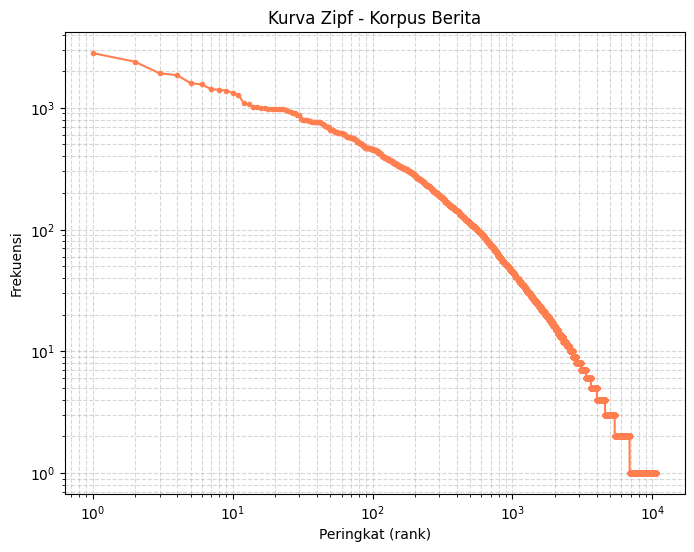

In [9]:
import matplotlib.pyplot as plt
from collections import Counter

semua_token_final = [t for doc in hasil_stem_all for t in doc]
frekuensi = Counter(semua_token_final)
frekuensi_terurut = sorted(frekuensi.values(), reverse=True)
peringkat = range(1, len(frekuensi_terurut) + 1)

plt.figure(figsize=(8,6))
plt.loglog(peringkat, frekuensi_terurut, marker='.', color='coral')
plt.xlabel('Peringkat (rank)')
plt.ylabel('Frekuensi')
plt.title('Kurva Zipf - Korpus Berita')
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.savefig('zipf_plot.png')
plt.show()

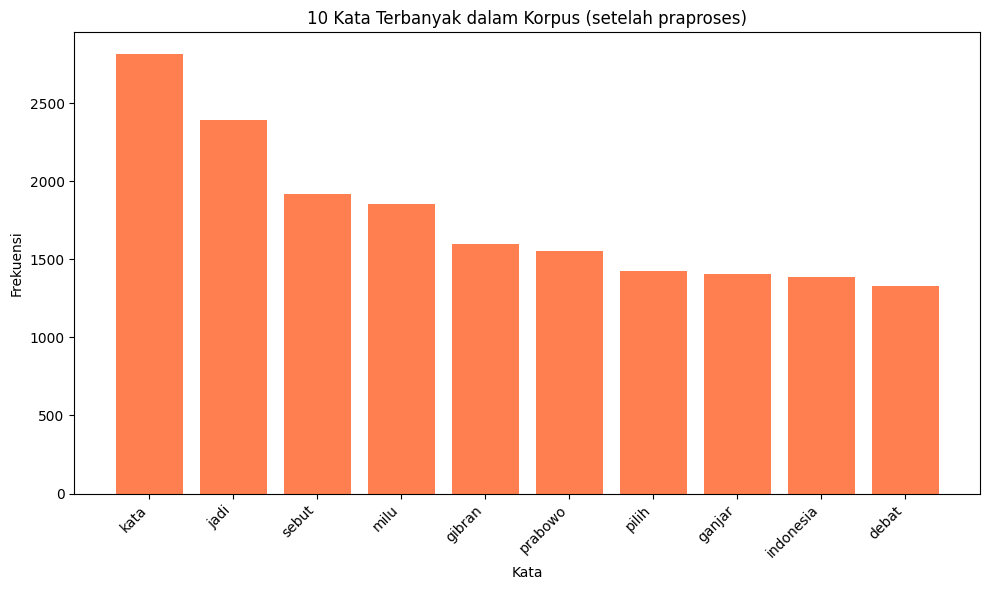

In [10]:
top_10 = frekuensi.most_common(10)
kata = [item[0] for item in top_10]
jumlah = [item[1] for item in top_10]

plt.figure(figsize=(10, 6))
plt.bar(kata, jumlah, color='coral')
plt.xlabel('Kata')
plt.ylabel('Frekuensi')
plt.title('10 Kata Terbanyak dalam Korpus (setelah praproses)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('top10_kata.png')
plt.show()

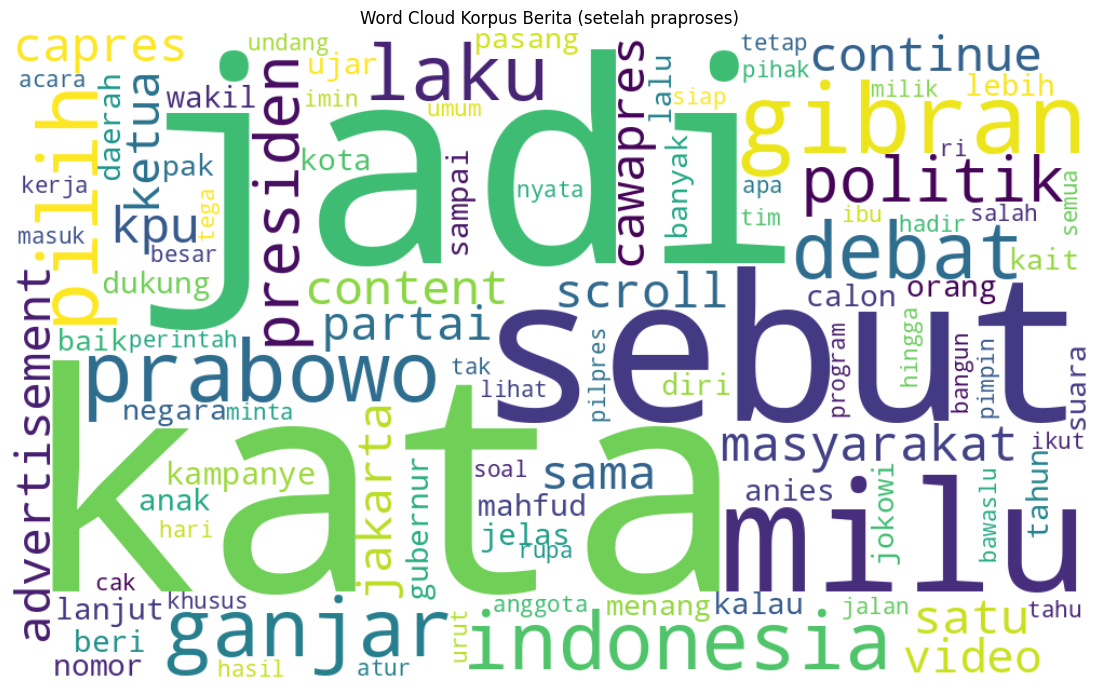

In [11]:
!pip install wordcloud -q

from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Gabungkan semua token hasil akhir jadi satu string
teks_gabungan = ' '.join(semua_token_final)

wc = WordCloud(
    width=1000,
    height=600,
    background_color='white',
    colormap='viridis',
    max_words=100,
    collocations=False
).generate(teks_gabungan)

plt.figure(figsize=(12, 7))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud Korpus Berita (setelah praproses)')
plt.tight_layout()
plt.savefig('wordcloud.png')
plt.show()

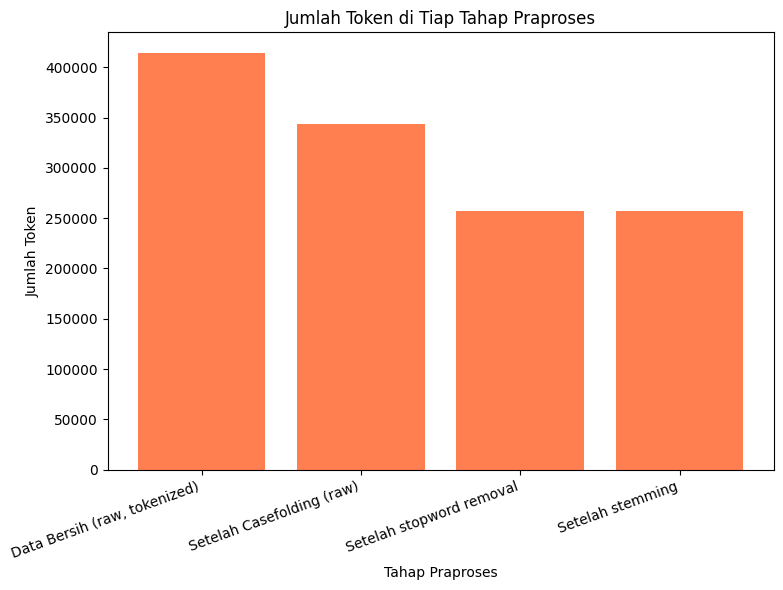

In [12]:
nama_tahap = list(tahap.keys())
jumlah_token_tiap_tahap = [hitung_statistik(data)[0] for data in tahap.values()]

plt.figure(figsize=(8, 6))
plt.bar(nama_tahap, jumlah_token_tiap_tahap, color='coral')
plt.xlabel('Tahap Praproses')
plt.ylabel('Jumlah Token')
plt.title('Jumlah Token di Tiap Tahap Praproses')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('token_per_tahap.png')
plt.show()

# Analisis dan Kesimpulan
Pada fase data bersih, banyak token yang tersedia ada 21.081, kemudian menurun sebanyak 3.857 menjadi 17.224 token karena adanya proses casefolding (penyamaan kapitalisasi huruf, penghapusan seluruh karakter bukan spasi dan alfabet kecil, dan perapian spasi). Pada bagian casefolding, beberapa tanda baca akan dihapus sehingga token tentu akan menjadi lebih kecil.

Sementara itu, pada fase stopword removal, pengurangan token terjadi sebesar 4.288 menjadi sebesar 12.956 token. Hal ini dikarenakan pengurangan kata tidak perlu pada library Sastrawi sehingga pengurangannya terlihat lebih jelas.

Terakhir, pada fase stemming, tidak ada token yang berkurang. Hal ini karena pada fase Stemming kita tidak mengurangi kata, tapi mengambil kata dasarnya. Namun, jumlah term justru berkurang karena beberapa kata dasar yang sama akan dihitung menjadi satu

Maka dari itu, dari ketiga tahapan ini, pengurangan token terbanyak terjadi pada fase stopword removal. Hal ini disebabkan adanya pengurangan kata secara signifikan pada pustaka stopword Sastrawi sehingga pengurangan kata pada fase ini menjadi 4.268.

# Penyimpanan dalam bentuk CSV

In [13]:
dataset_inverted = data_bersih[['title', 'article_text']].copy()

dataset_inverted['docID'] = range(len(dataset_inverted))
dataset_inverted['tokens_stemmed'] = hasil_stem_all

dataset_inverted = dataset_inverted[
    ['docID', 'title', 'article_text', 'tokens_stemmed']
]

dataset_inverted.to_csv(
    'dataset_inverted.csv',
    index=False
)

print(dataset_inverted.head())

   docID                                              title  \
0      0  Hasto Ingin Debat Pilpres Pertarungan Gagasan ...   
1      1  Terima Kunjungan Gibran di Ponpes Al-Tsaqafah,...   
2      2  Contoh Format dan Isi Surat Pernyataan Anggota...   
3      3  9 Ribu Personel Gabungan Dikerahkan Amankan Na...   
4      4  Amarah Ukraina Usai Rusia Bakal Gelar Pilpres ...   

                                        article_text  \
0  Sekjen PDIP sekaligus Sekretaris Tim Pemenang ...   
1  Mantan Ketua Umum Pengurus Besar Nahdlatul Ula...   
2  Surat pernyataan KPPS Pemilu 2024 merupakan ba...   
3  Sekitar 9.000 personel dikerahkan untuk mengam...   
4  Ukraina marah usai Rusia menjadikan empat wila...   

                                      tokens_stemmed  
0  [sekjen, pdip, sekaligus, sekretaris, tim, men...  
1  [mantan, ketua, umum, urus, besar, nahdlatul, ...  
2  [surat, nyata, kpps, milu, rupa, bagi, berkas,...  
3  [personel, kerah, aman, raya, natal, tahun, ba...  
4  [ukrai